In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

%matplotlib inline

In [7]:
## Dataset
from sklearn.datasets import make_blobs
x, y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [8]:
x

array([[  6.05591129,  -7.21607541],
       [  4.70657723,  -6.20731498],
       [ -7.67713268,  -8.30741483],
       ...,
       [  6.40398803,  -5.82757386],
       [ -6.22855904, -10.7924947 ],
       [  6.13025356,  -6.83862493]], shape=(1000, 2))

In [9]:
y

array([1, 1, 2, 1, 0, 1, 2, 2, 2, 1, 0, 0, 0, 2, 2, 0, 0, 2, 2, 0, 2, 0,
       2, 1, 0, 2, 2, 1, 0, 1, 1, 2, 1, 2, 2, 1, 0, 2, 1, 2, 1, 1, 2, 1,
       2, 0, 1, 0, 1, 1, 0, 2, 2, 0, 2, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 2, 0, 1, 2, 1, 1, 2, 2, 1, 2, 2, 0, 2, 1, 0, 2, 0, 2, 1, 0, 0,
       0, 0, 0, 0, 1, 2, 1, 2, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 2, 1, 1, 2,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 0, 1, 0, 2, 1, 1, 2, 0, 0, 2,
       0, 2, 1, 1, 1, 2, 0, 1, 2, 1, 0, 2, 0, 2, 1, 1, 2, 1, 1, 0, 0, 0,
       2, 0, 2, 0, 0, 2, 2, 1, 0, 1, 2, 2, 0, 1, 1, 2, 2, 2, 1, 1, 1, 1,
       0, 2, 2, 1, 0, 2, 0, 2, 0, 2, 1, 0, 2, 0, 2, 2, 0, 2, 1, 1, 0, 1,
       2, 0, 1, 2, 2, 0, 0, 1, 2, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 2, 2, 0,
       0, 0, 1, 2, 0, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 2, 0, 0, 1,
       0, 2, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 2, 1, 2, 0, 0, 0, 0, 0, 1,
       0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1, 2, 2,

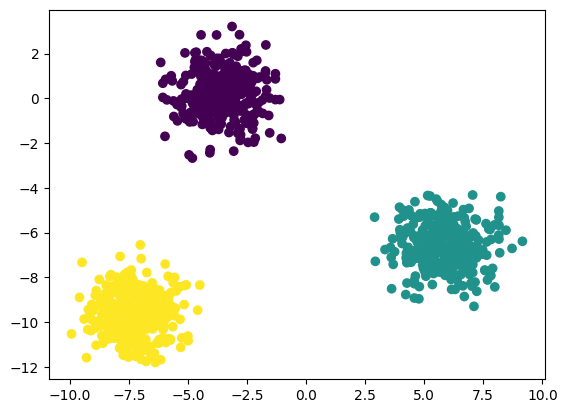

In [23]:
plt.scatter(x[:,0], x[:,1], c=y)

In [13]:
## Standardization --> feature Scaling
from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                    test_size = 0.33, random_state=42)

In [16]:
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

In [17]:
## Elbow Method to select the K-value
wcss = []   # Within Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(x_train_sc)
    wcss.append(kmeans.inertia_)

In [18]:
wcss

[1339.9999999999995,
 662.6482622432842,
 57.73401289200252,
 49.13041584426006,
 42.369509694236264,
 39.25531908222028,
 35.012916192962166,
 27.620444981908594,
 25.83444842548446,
 23.052643680686973]

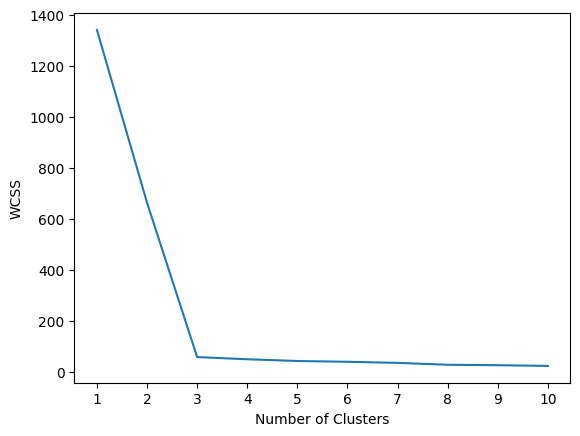

In [20]:
## Plot Elbow Curve
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
kmeans = KMeans(n_clusters=3, init="k-means++")
y_pred_train = kmeans.fit_predict(x_train_sc)
y_pred = kmeans.predict(x_test_sc)

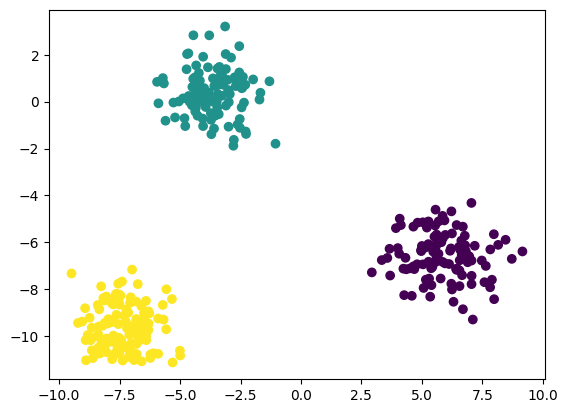

In [25]:
plt.scatter(x_test[:,0], x_test[:,1], c=y_pred)

## **Validating the K Value**

### Knee Locator

In [31]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [32]:
kl.elbow

np.int64(3)

### Silhoutte Scoring

In [33]:
from sklearn.metrics import silhouette_score
silhoutte_coefficients = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(x_train_sc)
    score=silhouette_score(x_train_sc, kmeans.labels_)
    silhoutte_coefficients.append(score)

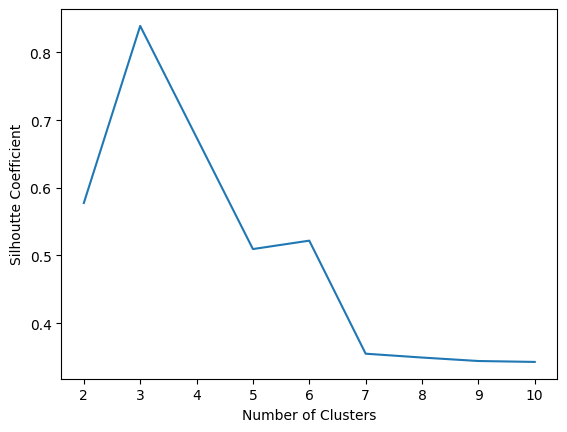

In [ ]:
## Plot Curve
plt.plot(range(2,11), silhoutte_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coefficient")
plt.show()